In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_rows', 1000)

op="mcscan"

current_path = os.getcwd()
directory = os.path.join(current_path) + "/../data/"
print(directory)
tot_dataframe = pd.DataFrame()
for root,dirs,files in os.walk(directory):
    for file in files:
       if (file.endswith(".csv")) and (op in file):
          csv_path=directory+file
          print(csv_path)
          data = pd.read_csv(csv_path)
          df = pd.DataFrame(data)
          tot_dataframe = pd.concat([tot_dataframe,df])

input_size = tot_dataframe['size'] * 2 + tot_dataframe['size'] # As I need to take as input a vector of SIZE elements of half, and a vector of INT8, hence size * 3
output_size = tot_dataframe['size'] * 4 # The output is in float, hence SIZE elements of 32 bits
tot_dataframe['mem_bytes'] = (tot_dataframe['size'] * (2 + 1))  + tot_dataframe['size'] * 4
print(tot_dataframe)

tot_dataframe['bandwidth_mbps'] = (tot_dataframe['mem_bytes']) / (tot_dataframe['time_us']) #MB/s


/scratch/gsorrentino/tcuscan/tmp_compress_profile_integration/pytorch-tcuscan/paper-plots/../data/
/scratch/gsorrentino/tcuscan/tmp_compress_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_mcscan_128_fp16.csv
/scratch/gsorrentino/tcuscan/tmp_compress_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_mcscan_64_fp16.csv
/scratch/gsorrentino/tcuscan/tmp_compress_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_mcscan_32_fp16.csv
      operator dtype      size  time_us  mem_bytes
0   mcscan_128  fp16    327680    71.60    2293760
1   mcscan_128  fp16   5570560   172.58   38993920
2   mcscan_128  fp16  10813440   277.81   75694080
3   mcscan_128  fp16  16056320   383.97  112394240
4   mcscan_128  fp16  21299200   489.79  149094400
5   mcscan_128  fp16  26542080   594.59  185794560
6   mcscan_128  fp16  31784960   735.37  222494720
7   mcscan_128  fp16  37027840   897.44  259194880
8   mcscan_128  fp16  42270720  1037.76  2958950

NameError: name 'ArrowDtype' is not defined

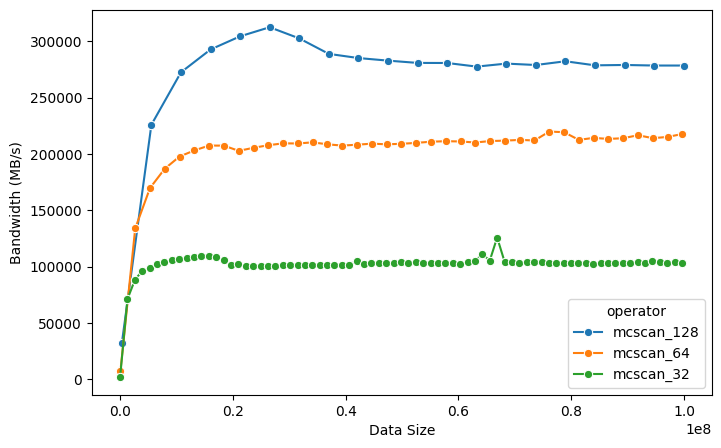

In [ ]:
plt.figure(figsize=(8, 5))
sns.lineplot(x='size', y='bandwidth_mbps', hue = 'operator', data=tot_dataframe, marker='o')

plt.xlabel('Data Size')
plt.ylabel('Bandwidth (MB/s)')
dtype = tot_dataframe['dtype'].tolist()
title = 'Bandwidth vs Data Size for ' + str(op) + ' with ' +  str(next(iter(s)))

plt.title(title)
plt.tight_layout()

plt.grid(True)
filename = op + ".pdf"
plt.savefig(filename)
plt.show()
